# FluoSpec 2 — canopy SIF post-processing on the bundled sample spectra (minimal reproduction)

**Paper:** Yang X., Shi H., Stovall A., Guan K., Miao G., Zhang Y., Zhang Y., Xiao X., Ryu Y., Lee J.-E. (2018). *FluoSpec 2-An Automated Field Spectroscopy System to Monitor Canopy Solar-Induced Fluorescence.* **Sensors 18(7):2063**, DOI [10.3390/s18072063](https://doi.org/10.3390/s18072063) (CC BY).

**Author code:** [zhangyaonju/seabreeze_control](https://github.com/zhangyaonju/seabreeze_control) @ commit `d6341ad3796131c549b7e952788f6077d9bcc768` (GPL-3.0), `processing.R`.

**Scope (partial demonstration).** This notebook runs the paper's **post-processing path** — dark subtraction, nonlinearity correction, calibration-factor conversion to spectral irradiance/radiance (mW m⁻² sr⁻¹ nm⁻¹), reflectance, and Spectral Fitting (SF) retrieval of SIF near 760 nm — on the **one bundled sample pair** (`test_data/QE_PRO_May__2_14_16_07_2017.csv`, `test_data/HR2000PLUS_May__2_14_15_01_2017.csv`, 2017-05-02). It is a one-example run, **not** a validation of the paper's field calibration accuracy or FluoNet results.

**Hardware acquisition (not reproduced).** The Raspberry Pi + Seabreeze C acquisition firmware (`RP3_fluorescence_v1.00.c`) drives real spectrometers through USB and cannot run headless; it is documented but omitted. SVD-based SIF retrieval and the wavelength-calibration spreadsheet are not present in the repository and are out of scope.

**Execution status / runtime.** This notebook runs the **author's R code verbatim** through `Rscript` (Python is only the launcher). It needs **no GPU** — select the **CPU runtime**.

**日本語要約:** このノートブックは FluoSpec 2（Sensors 2018）の著者 R コード（`processing.R`）をそのまま `Rscript` で実行し、同梱サンプル分光データ（2017-05-02 の QE-Pro と HR2000+ の1ペア）に対して、ダーク減算・非線形補正・キャリブレーション係数による放射輝度/入射光量変換・反射率・760 nm 近傍の SF 法による SIF 推定を再現します。GPU 不要（CPU ランタイム推奨）。計測ハードウェア制御（Raspberry Pi + Seabreeze）は対象外です。

**Adaptations (host-side only; all scientific operations are the author's):** file paths point to `/content/fluospec/...`; `pdf()` output is written as `png()` so figures are embedded as notebook outputs; `Sys.setlocale("LC_ALL","English")` is guarded for Linux; if the `rms` package cannot install, `ols()` falls back to `stats::lm` (numerically identical OLS coefficients, stated in the run log).

**Runtime selection.** The workload is a matrix pipeline on 10×1044 / 10×2048 spectra plus an 89-point OLS fit — seconds of CPU compute, no CUDA anywhere in the author code. Use **Runtime → Change runtime type → CPU** and then *Run all*. Expected total: a few minutes (dominated by the optional `rms` install and the ~0.6 MB of sample downloads).

**日本語:** 行列演算と 89 点の OLS のみで GPU 不要です。「ランタイム → ランタイムのタイプを変更 → CPU」を選び、すべて実行してください（数分で完了）。

In [ ]:
import shutil, subprocess
rscript = shutil.which("Rscript") or "/usr/bin/Rscript"
res = subprocess.run([rscript, "--version"], capture_output=True, text=True, timeout=60)
print((res.stderr or res.stdout).strip())
# confirm the R version that will run the author's script

Rscript (R) version 4.6.1 (2026-06-24)


**R dependency.** The author's `sif_retrival()` uses `rms::ols()`. We install `rms` from CRAN; if the install is slow or fails on the runtime, the driver automatically falls back to `stats::lm`, which yields numerically identical OLS coefficient estimates (the run log states which path was used).

**日本語:** 著者コードが使う `rms::ols()` を CRAN からインストールします。失敗時は同一の最小二乗推定を与える `stats::lm` へのフォールバックがドライバ内で自動適用され、ログに明記されます。

In [ ]:
rscript = shutil.which("Rscript") or "/usr/bin/Rscript"
cmd = [rscript, "-e",
       'install.packages("rms", repos="https://cloud.r-project.org"); '
       'cat("rms_available:", requireNamespace("rms", quietly=TRUE), "\n")']
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:          # stream progress; do not hide the install
    print(line, end="")
proc.wait(timeout=900)
print("exit:", proc.returncode)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


also installing the dependencies ‘zoo’, ‘gridExtra’, ‘Formula’, ‘MatrixModels’, ‘mvtnorm’, ‘TH.data’, ‘sandwich’, ‘checkmate’, ‘Hmisc’, ‘quantreg’, ‘SparseM’, ‘polspline’, ‘multcomp’, ‘htmlTable’, ‘colorspace’

trying URL 'https://cloud.r-project.org/src/contrib/zoo_1.9-1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/gridExtra_2.3.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/Formula_1.2-6.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/MatrixModels_0.5-4.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/mvtnorm_1.4-2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/TH.data_1.1-5.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/sandwich_3.1-3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/checkmate_2.3.4.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/Hmisc_5.3-0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/quantreg_6.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/co

* installing *source* package ‘zoo’ ...
** this is package ‘zoo’ version ‘1.9-1’
** package ‘zoo’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘x86_64-linux-gnu-gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0’
x86_64-linux-gnu-gcc -std=gnu2x -I"/usr/share/R/include" -DNDEBUG -I../inst/include      -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3  -c coredata.c -o coredata.o


x86_64-linux-gnu-gcc -std=gnu2x -I"/usr/share/R/include" -DNDEBUG -I../inst/include      -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3  -c init.c -o init.o
x86_64-linux-gnu-gcc -std=gnu2x -I"/usr/share/R/include" -DNDEBUG -I../inst/include      -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3  -c lag.c -o lag.o


x86_64-linux-gnu-gcc -std=gnu2x -shared -L/usr/lib/R/lib -Wl,-Bsymbolic-functions -flto=auto -ffat-lto-objects -Wl,-z,relro -o zoo.so coredata.o init.o lag.o -L/usr/lib/R/lib -lR
installing to /usr/local/lib/R/site-library/00LOCK-zoo/00new/zoo/libs
** R
** demo
** inst
** byte-compile and prepare package for lazy loading


...

** building package indices


** testing if installed package can be loaded from temporary location


** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location


** testing if installed package keeps a record of temporary installation path
* DONE (rms)

The downloaded source packages are in
	‘/tmp/RtmpgrUrO3/downloaded_packages’


rms_available: TRUE 
exit: 0


**Sample acquisition (inside Colab only).** We fetch the exact pinned files from the author repository at commit `d6341ad…` via `raw.githubusercontent.com`: the four calibration files `processing.R` reads (`configuration/new_{QE,HR}_{CC,BF}_1001.csv`) and the two bundled test spectra. Expected byte sizes come from the pinned GitHub tree listing and are asserted after download; a size mismatch or an HTML error page aborts the notebook.

**日本語:** 著者リポジトリの固定コミットから、キャリブレーション CSV 4 ファイルとテスト用スペクトル 2 ファイルのみを Colab 内にダウンロードし、バイト数を検証します（不一致や HTML エラーページは中断）。

In [ ]:
import urllib.request, pathlib

BASE = ("https://raw.githubusercontent.com/zhangyaonju/seabreeze_control/"
        "d6341ad3796131c549b7e952788f6077d9bcc768/")
FILES = {  # path in repo -> expected size in bytes (pinned GitHub tree listing, checked 2026-10-03)
    "configuration/new_QE_CC_1001.csv": 29037,
    "configuration/new_QE_BF_1001.csv": 30119,
    "configuration/new_HR_CC_1001.csv": 57626,
    "configuration/new_HR_BF_1001.csv": 60274,
    "test_data/QE_PRO_May__2_14_16_07_2017.csv": 181504,
    "test_data/HR2000PLUS_May__2_14_15_01_2017.csv": 263192,
}
root = pathlib.Path("/content/fluospec")
for rel, size in FILES.items():
    dest = root / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    if not dest.exists() or dest.stat().st_size != size:
        urllib.request.urlretrieve(BASE + rel, dest)   # public raw URL, no credentials
    assert dest.stat().st_size == size, (rel, dest.stat().st_size, size)
    head = dest.read_bytes()[:16]
    assert not head.lstrip().startswith(b"<"), f"HTML error page for {rel}"
print("downloaded and size-verified:", len(FILES), "files under", root)

downloaded and size-verified: 6 files under /content/fluospec


**Input preview.** Before the science, we inspect the actual downloaded sample: the QE-Pro CSV header lines (date, temperatures, nonlinearity coefficients, integration times, dark spectra) and a plot of the 10 raw spectrum rows (5 irradiance/radiance pairs, counts vs wavelength). This is a raw-data view only; the calibrated processing below is done by the author's R code.

**日本語:** 実行前にサンプルの実データを確認します。QE-Pro CSV のヘッダ（日時・温度・非線形係数・積算時間・ダークスペクトル）と、生スペクトル 10 行（入射/放射 5 ペア、カウント値）をプロットします。

line  0: observation date and time: Tue May  2 14:16:07 2017
line  1: 
line  2: spectrometer: QE-PRO
line  3: ambient temperature: 14.34
line  4: measuring temperature: -9.85
line  5: nonlinearity correction coefficients:
line  6: 9.824680e-01,5.089400e-07,4.484960e-12,-4.155470e-16,7.607490e-21,-6.487400e-26,2.669500e-31,-4.2723
line  7: 729.173767,729.244572,729.315351,729.386102,729.456827,729.527525,729.598196,729.668840,729.739458,7
line  8: integration time 1: 2349931
line  9: 1587.000000,1579.000000,1574.000000,1574.000000,1606.000000,1617.000000,1621.000000,1613.000000,1618
line 10: integration time 2: 1675680
line 11: 1583.000000,1574.000000,1577.000000,1571.000000,1601.000000,1605.000000,1611.000000,1602.000000,1608
wavelength: (1044,) (729.17-788.46 nm);  spectrum matrix: (10, 1044)


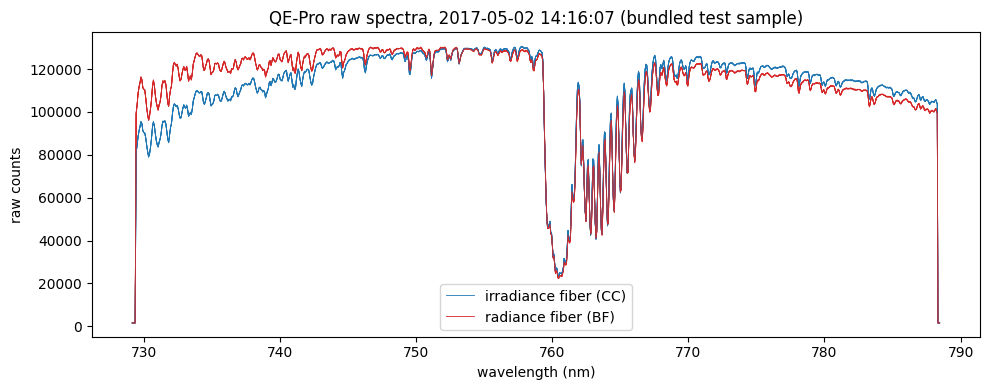

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

qe_path = "/content/fluospec/test_data/QE_PRO_May__2_14_16_07_2017.csv"
lines = open(qe_path).read().splitlines()
for i, l in enumerate(lines[:12]):
    print(f"line {i:2d}: {l[:100]}")

hdr_idx = [i for i, l in enumerate(lines[:12]) if l.lower().startswith("nonlinearity")][0]
def _f(v):
    try: return float(v)
    except ValueError: return None
# header order: label line, nonlinearity coefficients, then the wavelength vector
wl_idx = hdr_idx + 2
wl = np.array([_f(v) for v in lines[wl_idx].split(",")])
wl = wl[wl != None]  # noqa: E711  (drop any trailing blanks)
assert wl.min() > 500, "wavelength vector not found after the coefficients line"
spec = np.loadtxt(qe_path, skiprows=12, delimiter=",")
assert len(wl) == spec.shape[1], (len(wl), spec.shape)
print("wavelength:", wl.shape, f"({wl.min():.2f}-{wl.max():.2f} nm);  spectrum matrix:", spec.shape)

plt.figure(figsize=(10, 4))
for i in range(spec.shape[0]):
    lbl = "irradiance fiber (CC)" if i % 2 == 0 else "radiance fiber (BF)"
    plt.plot(wl, spec[i], lw=0.6, color="tab:blue" if i % 2 == 0 else "tab:red",
             label=lbl if i < 2 else None)
plt.xlabel("wavelength (nm)"); plt.ylabel("raw counts")
plt.title("QE-Pro raw spectra, 2017-05-02 14:16:07 (bundled test sample)")
plt.legend(); plt.tight_layout()
plt.savefig("/content/fluospec/out_preview_qe_raw.png", dpi=120, bbox_inches="tight")
plt.show()

**Author pipeline (verbatim) + driver.** The cell below writes `fluospec_run.R` to `/content`. It contains the author's `processing.R` functions **copied verbatim** (`read_QE_pro`, `read_HR2k`, `nonlinearity_correction_QE/HR`, `irradiance_calc_QE/HR`, `reflectance`, `sif_retrival`), followed by a short driver that runs them on the single QE/HR sample pair (the two files are 66 s apart and are treated as the paired sample — the repository's multi-file diurnal loop is reduced to this one timestamp). Adaptations are limited to: paths under `/content/fluospec/`, `png()` instead of `pdf()`, a guarded `Sys.setlocale`, and the `rms`→`lm` fallback.

Mapping to the paper (Section 2.2–2.3, FluoSpec 2 processing): dark subtraction + nonlinearity correction → calibration factors with solid angle/area/integration time/pixel bandwidth → irradiance (cosine-corrector fiber) and radiance (bare fiber) in mW m⁻² sr⁻¹ nm⁻¹ → reflectance = radiance/irradiance → SIF by Spectral Fitting over 759.03–764.07 nm (89 pixels, indices 463:551).

**日本語:** 著者の `processing.R` の関数を一字一句そのまま含み、同梱サンプル 1 ペアに適用するドライバを `/content` に書き込みます。変更はパス・png 出力・locale ガード・rms フォールバックのみです。

In [ ]:
import pathlib
R_SCRIPT = r'''#### FluoSpec 2 post-processing — minimal single-sample driver
#### Author functions copied VERBATIM from processing.R
#### (zhangyaonju/seabreeze_control @ d6341ad3796131c549b7e952788f6077d9bcc768, GPL-3.0)
#### Host-side adaptations ONLY: paths -> /content/fluospec/..., pdf() -> png(),
#### Sys.setlocale guarded for Linux, stats::lm fallback if the rms package is unavailable.
#### All scientific operations are the author's original R code.

tryCatch(Sys.setlocale("LC_ALL","English"), error=function(e) NULL, warning=function(w) NULL)

if (requireNamespace("rms", quietly=TRUE)) {
  library(rms)
} else {
  message("rms unavailable: using stats::lm (identical OLS coefficient estimates)")
  ols <- function(formula, ...) lm(formula, ...)
}

jet.colors <- colorRampPalette(c("#00007F", "blue", "#007FFF", "cyan",
                                 "#7FFF7F", "yellow", "#FF7F00", "red", "#7F0000"))(6)

read_QE_pro<-function(filename){
  #filename<-"F:/FluoSpec_data/test/QE_PRO_Jul_18_16_00_40_2016.csv"
  con<-file(filename,open="r")
  temp_str<-readLines(con, n=1)
  datetime<-as.POSIXlt(strptime(substr(temp_str,28,60),format="%a %b %d %H:%M:%S %Y"))
  readLines(con, n=1)
  readLines(con, n=1)
  temp_str<-readLines(con, n=1)
  ambient_t<-as.numeric(strsplit(temp_str,": ")[[1]][2])
  temp_str<-readLines(con, n=1)
  measurement_t<-as.numeric(strsplit(temp_str,": ")[[1]][2])
  readLines(con, n=1)
  temp_str<-readLines(con, n=1)
  nonlinearity_correction_factor<-as.numeric(strsplit(temp_str,",")[[1]])
  temp_str<-readLines(con, n=1)
  wavelength<-as.numeric(strsplit(temp_str,",")[[1]])
  temp_str<-readLines(con, n=1)
  inte_t1<-as.numeric(strsplit(temp_str,": ")[[1]][2])
  temp_str<-readLines(con, n=1)
  spectrum_dark1<-as.numeric(strsplit(temp_str,",")[[1]])
  temp_str<-readLines(con, n=1)
  inte_t2<-as.numeric(strsplit(temp_str,": ")[[1]][2])
  temp_str<-readLines(con, n=1)
  spectrum_dark2<-as.numeric(strsplit(temp_str,",")[[1]])
  close(con)
  spectrum<-as.matrix(read.csv(filename,skip = 12,header = F))
  QE_data<-list(datetime=datetime,ambient_t=ambient_t,measurement_t=measurement_t,
                nonlinearity_correction_factor=nonlinearity_correction_factor,
                wavelength=wavelength,
                inte_t1=inte_t1,spectrum_dark1=spectrum_dark1,
                inte_t2=inte_t2,spectrum_dark2=spectrum_dark2,spectrum=spectrum)
  return(QE_data)
}

read_HR2k<-function(filename){
  con<-file(filename,open="r")
  temp_str<-readLines(con, n=1)
  datetime<-as.POSIXlt(strptime(substr(temp_str,28,60),format="%a %b %d %H:%M:%S %Y"))
  readLines(con, n=1)
  readLines(con, n=1)
  temp_str<-readLines(con, n=1)
  temp_str<-readLines(con, n=1)
  temp_str<-readLines(con, n=1)
  nonlinearity_correction_factor<-as.numeric(strsplit(temp_str,",")[[1]])
  temp_str<-readLines(con, n=1)
  wavelength<-as.numeric(strsplit(temp_str,",")[[1]])
  temp_str<-readLines(con, n=1)
  inte_t1<-as.numeric(strsplit(temp_str,": ")[[1]][2])
  temp_str<-readLines(con, n=1)
  inte_t2<-as.numeric(strsplit(temp_str,": ")[[1]][2])
  close(con)
  spectrum<-as.matrix(read.csv(filename,skip = 10,header = F))
  HR_data<-list(datetime=datetime,wavelength=wavelength,
                nonlinearity_correction_factor=nonlinearity_correction_factor,
                inte_t1=inte_t1,inte_t2=inte_t2,spectrum=spectrum)
}

nonlinearity_correction_QE<-function(QE_data){
  obs<-dim(QE_data$spectrum)[1]/2
  dark_measurement_irr<-mean(QE_data$spectrum[c(1,3,5,7,9),c(1:4,1041:1044)])
  dark_measurement_rad<-mean(QE_data$spectrum[c(2,4,6,8,10),c(1:4,1041:1044)])
  edark<-rep(c(dark_measurement_irr,dark_measurement_rad),5*1044)
  dim(edark)<-c(obs*2,dim(QE_data$spectrum)[2])
  QE_data$spectrum_dark1<-QE_data$spectrum_dark1-mean(QE_data$spectrum_dark1[c(1:4,1041:1044)])
  QE_data$spectrum_dark2<-QE_data$spectrum_dark2-mean(QE_data$spectrum_dark2[c(1:4,1041:1044)])
  dark_measurement<-rep(c(QE_data$spectrum_dark1,QE_data$spectrum_dark2),obs)
  dim(dark_measurement)<-c(dim(QE_data$spectrum)[2],obs*2)
  dark_measurement<-t(dark_measurement)
  dark_corr<-QE_data$spectrum-dark_measurement-edark
  corr_factor<-QE_data$nonlinearity_correction_factor
  nonlinearity_corrected<-dark_corr/(corr_factor[1]+corr_factor[2]*dark_corr+corr_factor[3]*dark_corr^2+
                                       corr_factor[4]*dark_corr^3+corr_factor[5]*dark_corr^4+
                                       corr_factor[6]*dark_corr^5+corr_factor[7]*dark_corr^6+
                                       corr_factor[8]*dark_corr^7)
  return(nonlinearity_corrected)
}

nonlinearity_correction_HR<-function(HR_data){
  obs<-dim(HR_data$spectrum)[1]/2
  dark_measurement_irr<-mean(HR_data$spectrum[c(1,3,5,7,9),1:18])
  dark_measurement_rad<-mean(HR_data$spectrum[c(2,4,6,8,10),1:18])
  dark_measurement<-rep(c(dark_measurement_irr,dark_measurement_rad),5*2048)
  dim(dark_measurement)<-c(obs*2,dim(HR_data$spectrum)[2])
  dark_corr<-HR_data$spectrum-dark_measurement
  corr_factor<-HR_data$nonlinearity_correction_factor
  nonlinearity_corrected<-dark_corr/(corr_factor[1]+corr_factor[2]*dark_corr+corr_factor[3]*dark_corr^2+
                                       corr_factor[4]*dark_corr^3+corr_factor[5]*dark_corr^4+
                                       corr_factor[6]*dark_corr^5+corr_factor[7]*dark_corr^6+
                                       corr_factor[8]*dark_corr^7)
  return(nonlinearity_corrected)
}

irradiance_calc_QE<-function(QE_data,nonlinearity_corrected,QE_CC,QE_BF){
  sr_bf<-0.153721       #solid angle for bare fiber
  sr_cc<-pi             #solid angle for cosine corrector
  area_bf<-0.25*pi*1e-6      # area of the bare fiber, in m^2
  area_cc<-1.95*1.95*pi*1e-6 # area of the cosine corrector, in m^2
  wavelength_spread_QE<-59.28809/1043     #band width for each ccd pixel
  obs<-dim(QE_data$spectrum)[1]/2         # five pairs of observation, 1,3,5,7,9 for irradiance, 2,4,6,8,10 for radiance
  factor<-rep(c(QE_CC[,2]/sr_cc/(QE_data$inte_t1/1e6)/area_cc/wavelength_spread_QE/1e3,
                QE_BF[,2]/sr_bf/(QE_data$inte_t2/1e6)/area_bf/wavelength_spread_QE/1e3),obs)
  #this factor used to convert count to mW/m2/sr/nm
  dim(factor)<-c(dim(QE_data$spectrum)[2],obs*2)
  factor<-t(factor)
  factor[,c(1:4,1041:1044)]<-NA
  irradiance_flux<-factor*nonlinearity_corrected
  irradiance_flux[,c(1:4,1041:1044)]<-NA
  return(irradiance_flux)
}

irradiance_calc_HR<-function(HR_data,nonlinearity_corrected,HR_CC,HR_BF){
  sr_bf<-0.153721
  sr_cc<-pi
  area_bf<-0.25*pi*1e-6
  area_cc<-1.95*1.95*pi*1e-6
  wavelength_spread_HR<-918.1482/2047
  obs<-dim(HR_data$spectrum)[1]/2
  factor<-rep(c(HR_CC[,2]/sr_cc/(HR_data$inte_t1/1e6)/area_cc/wavelength_spread_HR/1e3,
                HR_BF[,2]/sr_bf/(HR_data$inte_t2/1e6)/area_bf/wavelength_spread_HR/1e3),obs)
  #this factor used to convert count to mW/m2/sr/nm
  dim(factor)<-c(dim(HR_data$spectrum)[2],obs*2)
  factor<-t(factor)
  factor[,c(1:18)]<-NA
  irradiance_flux<-factor*nonlinearity_corrected
  irradiance_flux[,c(1:18)]<-NA
  return(irradiance_flux)
}

reflectance<-function(irradiance_flux){
  obs<-dim(irradiance_flux)[1]/2
  irr_i<-1:obs*2-1
  rad_i<-1:obs*2
  irr<-irradiance_flux[irr_i,]
  rad<-irradiance_flux[rad_i,]
  reflectance<-rad/irr
  return(reflectance)
}

sif_retrival<-function(irradiance,radiance){
  ####wavelength number for 759.0321-764.0709
  ##########################   463     551
  rin<-irradiance[463:551]
  rout<-radiance[463:551]
  x=1:89
  rin[is.na(rin)]<-0
  if((sum(rin==0)==89)||(sum(rout==0)==89)){
    return(NA)
  }
  res<-ols(rout~x*rin+rin+x)
  re_coeff<-coefficients(res)
  rio<-re_coeff[4]*x+re_coeff[3]
  sif1<-re_coeff[2]*x+re_coeff[1]
  rsq<-(cor.test(rout,(rio*rin+sif1))$estimate)^2
  return(c(sif1,rsq))
}


#### ---- Driver: bundled May 2 2017 sample pair (paths adapted to /content) ----
cfg_dir <- "/content/fluospec/configuration"
dat_dir <- "/content/fluospec/test_data"
out_dir <- "/content/fluospec/out"
dir.create(out_dir, showWarnings=FALSE, recursive=TRUE)

QE_CC<-read.csv(file.path(cfg_dir,"new_QE_CC_1001.csv"),header = T)[,1:2]
QE_BF<-read.csv(file.path(cfg_dir,"new_QE_BF_1001.csv"),header = T)[,1:2]
HR_CC<-read.csv(file.path(cfg_dir,"new_HR_CC_1001.csv"),header = T)[,1:2]
HR_BF<-read.csv(file.path(cfg_dir,"new_HR_BF_1001.csv"),header = T)[,1:2]

filename_QE<-list.files(dat_dir, pattern="QE_PRO", full.names = T)
filename_HR<-list.files(dat_dir, pattern="HR2000PLUS", full.names = T)
stopifnot(length(filename_QE)==1, length(filename_HR)==1)

qe_data<-read_QE_pro(filename_QE)
if (median(qe_data$spectrum_dark1)>2500)
  stop("author skip condition hit: dark median > 2500")
nonlinearity_corrected_QE<-nonlinearity_correction_QE(qe_data)
irradiance_flux_QE<-irradiance_calc_QE(qe_data,nonlinearity_corrected_QE,QE_CC,QE_BF)
reflectance_QE<-reflectance(irradiance_flux_QE)
sif<-array(NA,dim=c(90,5))
for (i in 1:5){
  sif[,i]<-sif_retrival(irradiance_flux_QE[i*2-1,],irradiance_flux_QE[i*2,])
}

hr_data<-read_HR2k(filename_HR)
nonlinearity_corrected_HR<-nonlinearity_correction_HR(hr_data)
irradiance_flux_HR<-irradiance_calc_HR(hr_data,nonlinearity_corrected_HR,HR_CC,HR_BF)
reflectance_HR<-reflectance(irradiance_flux_HR)

# results table mirroring the author's diurnal_sif columns (one row for this sample)
diurnal_sif<-data.frame(date=format(qe_data$datetime),
  SIF1=sif[18,1],SIF2=sif[18,2],SIF3=sif[18,3],SIF4=sif[18,4],SIF5=sif[18,5],
  RSQ1=sif[90,1],RSQ2=sif[90,2],RSQ3=sif[90,3],RSQ4=sif[90,4],RSQ5=sif[90,5],
  temp_ambient=qe_data$ambient_t, temp_measure=qe_data$measurement_t,
  irr_750_QE1=irradiance_flux_QE[1,314], irr_750_HR1=irradiance_flux_HR[1,1225])
write.csv(diurnal_sif, file.path(out_dir,"sif_results.csv"), row.names=FALSE)

# ---- QE-Pro figure: irradiance/radiance, reflectance, SIF (author's panel code) ----
png(file.path(out_dir,"fluospec_qe_20170502.png"), width=1400, height=2100, res=120)
par(fig=c(0,1,0.66,1),mar=c(4,5,4,5)+0.5)
plot(NA,ylim=c(0,max(irradiance_flux_QE,na.rm = T)*1.1),xlim=c(min(qe_data$wavelength),max(qe_data$wavelength)),
     main=qe_data$datetime,
     ylab=expression("[mW m"^-2~"sr"^-1~"nm"^-1~"]"),
     xlab="wavelength (nm)",cex.lab=1.25)
for (i in 1:10){
  lines(qe_data$wavelength,irradiance_flux_QE[i,],col=jet.colors[ceiling(i/2)],lty=i%%2+1)
}
legend("bottomright",legend=c("irradiance (CC)","radiance (BF)"),lty=c(2,1),y.intersp=1,bty="n")

par(fig=c(0,1,0.33,0.66),mar=c(4,5,4,5)+0.5,new=T)
plot(NA,ylim=c(0,1),xlim=c(min(qe_data$wavelength),max(qe_data$wavelength)),
     main=qe_data$datetime,ylab=expression("reflectance"),xlab="wavelength (nm)",cex.lab=1.25)
for (i in 1:5){
  lines(qe_data$wavelength,reflectance_QE[i,],col=jet.colors[i],lty=1)
}

par(fig=c(0,1,0,0.33),mar=c(4,5,4,5)+0.5,new=T)
plot(NA,ylim=c(0,5),xlim=c(qe_data$wavelength[463],qe_data$wavelength[551]),
     main="SIF (SF retrieval, 759.03-764.07 nm)",
     ylab=expression("[mW m"^-2~"sr"^-1~"nm"^-1~"]"),
     xlab="wavelength (nm)",cex.lab=1.25)
for (i in 1:5){
  lines(qe_data$wavelength[463:551],sif[1:89,i],col=jet.colors[i],lty=1)
}
dev.off()

# ---- HR2000+ figure: irradiance/radiance, reflectance ----
png(file.path(out_dir,"fluospec_hr_20170502.png"), width=1400, height=1400, res=120)
par(fig=c(0,1,0.5,1),mar=c(4,5,4,5)+0.5)
plot(NA,ylim=c(0,max(irradiance_flux_HR[,500:1500],na.rm = T)*1.1),xlim=c(min(hr_data$wavelength),max(hr_data$wavelength)),
     main=hr_data$datetime,
     ylab=expression("[mW m"^-2~"sr"^-1~"nm"^-1~"]"),
     xlab="wavelength (nm)",cex.lab=1.25)
for (i in 1:10){
  lines(hr_data$wavelength,irradiance_flux_HR[i,],col=jet.colors[ceiling(i/2)],lty=i%%2+1)
}
legend("bottomright",legend=c("irradiance (CC)","radiance (BF)"),lty=c(2,1),y.intersp=1,bty="n")

par(fig=c(0,1,0,0.5),mar=c(4,5,4,5)+0.5,new=T)
plot(NA,ylim=c(0,1),xlim=c(min(hr_data$wavelength),max(hr_data$wavelength)),
     main=hr_data$datetime,ylab=expression("reflectance"),xlab="wavelength (nm)",cex.lab=1.25)
for (i in 1:5){
  lines(hr_data$wavelength,reflectance_HR[i,],col=jet.colors[i],lty=1)
}
dev.off()

cat("QE datetime :", format(qe_data$datetime), "\n")
cat("QE wavelength range:", min(qe_data$wavelength), "-", max(qe_data$wavelength), "nm\n")
cat("HR wavelength range:", min(hr_data$wavelength), "-", max(hr_data$wavelength), "nm\n")
cat("SIF_760 (5 replicate pairs) [mW m-2 sr-1 nm-1]:", sprintf("%.4f", sif[18,]), "\n")
cat("SF fit R^2:", sprintf("%.4f", sif[90,]), "\n")
cat("irradiance @ 750 nm QE:", sprintf("%.3f", irradiance_flux_QE[1,314]),
    " HR:", sprintf("%.3f", irradiance_flux_HR[1,1225]), "\n")
cat("figures written to:", out_dir, "\n")
'''
pathlib.Path('/content/fluospec_run.R').write_text(R_SCRIPT, encoding='utf-8')
print(len(R_SCRIPT.splitlines()), 'lines written to /content/fluospec_run.R')

272 lines written to /content/fluospec_run.R


**Execute the author's pipeline.** We run `Rscript /content/fluospec_run.R` with `check=True` and a finite timeout, streaming stdout/stderr so any failure stays visible. The script prints the sample metadata, the five replicate SIF_760 values with fit R², and the 750 nm irradiance anchors, and writes two PNG figures plus `sif_results.csv` (a one-row equivalent of the author's `diurnal_sif` table).

**日本語:** `Rscript` で著者のパイプラインを実行します。出力はすべて表示され、SIF_760（5 反復）・R²・750 nm 入射光量、2 枚の PNG と結果 CSV が生成されます。

In [ ]:
import subprocess, time
t0 = time.time()
proc = subprocess.run(["/usr/bin/Rscript", "/content/fluospec_run.R"],
                      text=True, capture_output=True, timeout=600)
print(proc.stdout)
if proc.stderr.strip():
    print("[stderr]", proc.stderr.strip())
proc.check_returncode()
print(f"Rscript finished OK in {time.time()-t0:.1f} s")

NULL
null device 
          1 
null device 
          1 
QE datetime : 2017-05-02 14:16:07 
QE wavelength range: 729.1738 - 788.4619 nm
HR wavelength range: 187.1418 - 1105.29 nm
SIF_760 (5 replicate pairs) [mW m-2 sr-1 nm-1]: -0.2896 -0.2652 -0.2508 -0.3181 -0.2328 
SF fit R^2: 0.9895 0.9893 0.9894 0.9895 0.9895 
irradiance @ 750 nm QE: 751.506  HR: 583.560 
figures written to: /content/fluospec/out 

[stderr] Loading required package: Hmisc

Attaching package: ‘Hmisc’

The following objects are masked from ‘package:base’:

    format.pval, units
Rscript finished OK in 4.6 s


**Processed results.** Display the saved figures. Top: QE-Pro calibrated irradiance (cosine-corrector fiber, dashed) and radiance (bare fiber, solid) in mW m⁻² sr⁻¹ nm⁻¹, QE reflectance, and the SF-retrieved SIF spectra in the 759–764 nm O₂-A fitting window. Bottom: the same for the HR2000+ spectrometer. These are the author's own panel layouts, rendered from the actual sample.

**日本語:** 保存された図を表示します。QE-Pro の較正済み入射光量/放射輝度、反射率、および 759–764 nm 窓での SF 法 SIF 推定スペクトル、さらに HR2000+ の結果です。

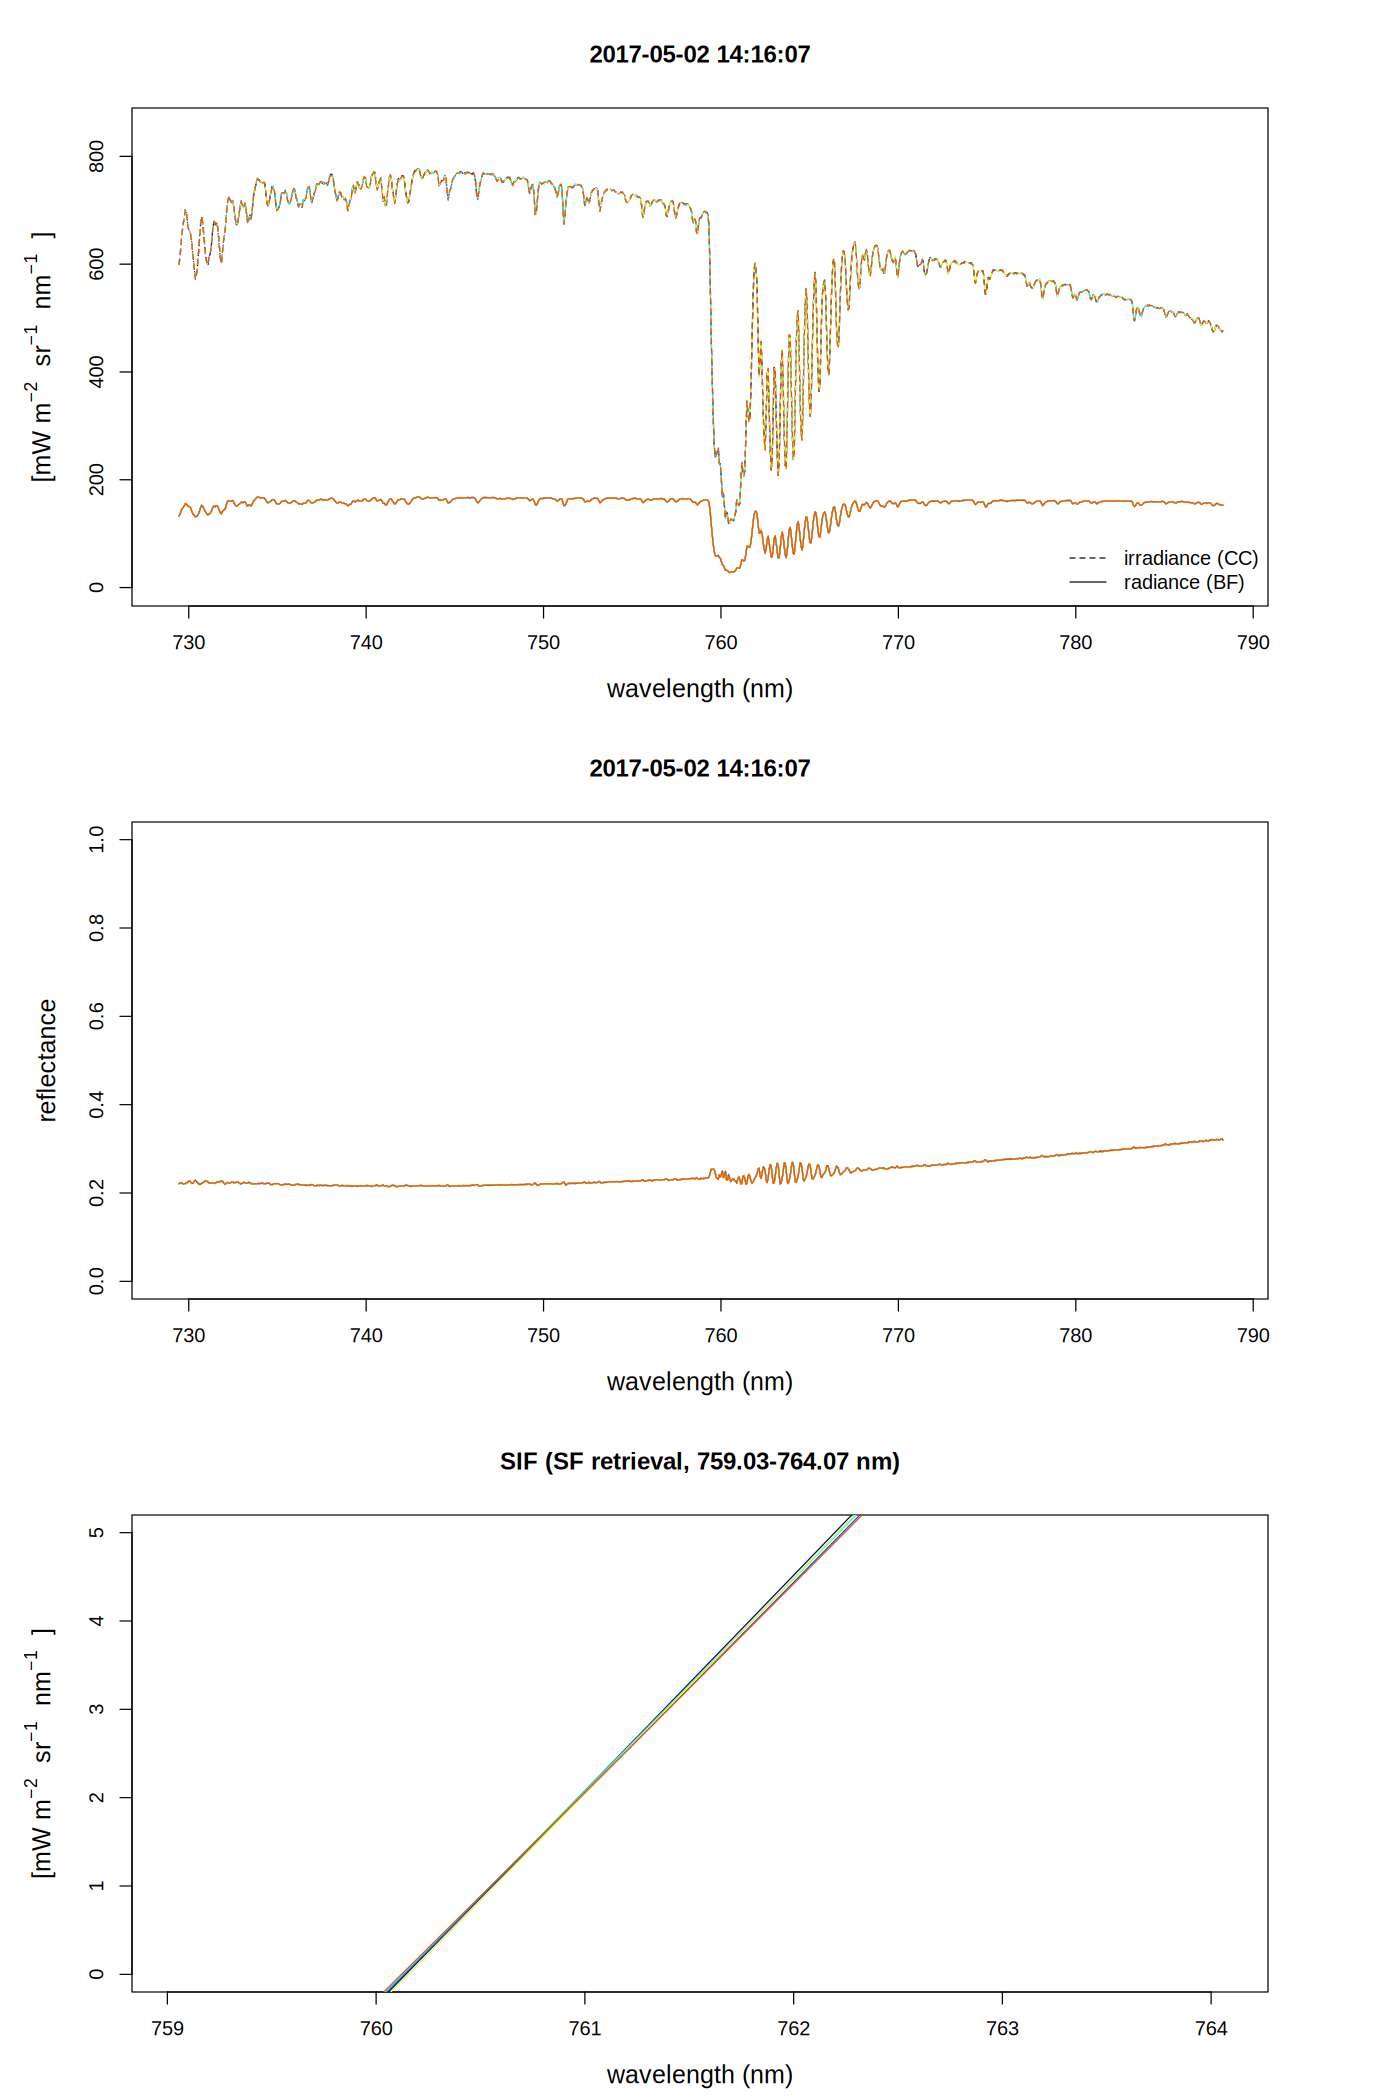

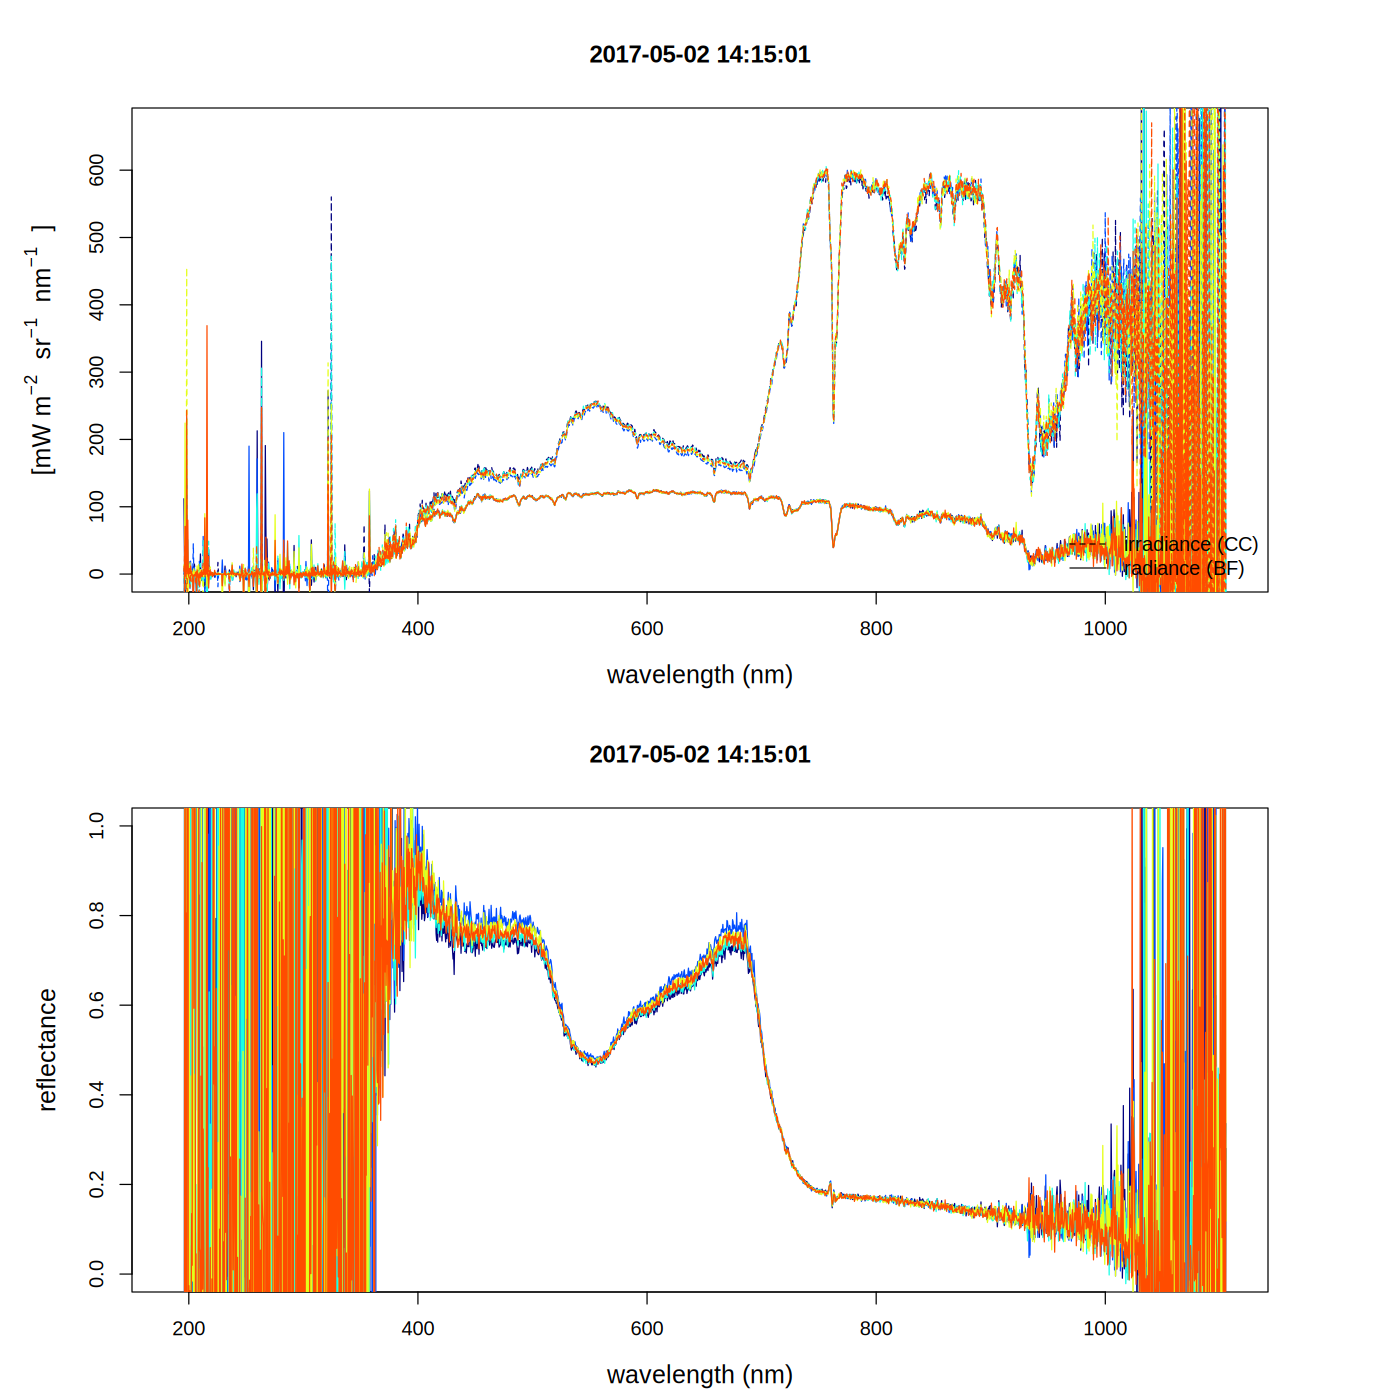

In [ ]:
from IPython.display import Image, display
for name in ["fluospec_qe_20170502.png", "fluospec_hr_20170502.png"]:
    display(Image(filename=f"/content/fluospec/out/{name}", width=640))

**Quantitative results.** The one-row table below mirrors the columns of the author's `diurnal_sif` output: five SIF_760 replicate estimates and their SF fit R², spectrometer temperatures, and 750 nm irradiance anchors. It is also saved as CSV for export. Values are in mW m⁻² sr⁻¹ nm⁻¹ (SIF, irradiance) and dimensionless (R², reflectance).

**日本語:** 著者の `diurnal_sif` 列に対応する結果表です。SIF_760 の 5 反復推定値と R²、温度、750 nm 入射光量を含み、CSV としても保存されます。

In [ ]:
import pandas as pd
df = pd.read_csv("/content/fluospec/out/sif_results.csv")
display(df.T)
df.to_csv("/content/fluospec/sif_results_export.csv", index=False)
print("saved: /content/fluospec/sif_results_export.csv")

,0
date,2017-05-02 14:16:07
SIF1,-0.289556
SIF2,-0.265207
SIF3,-0.250751
SIF4,-0.318075
SIF5,-0.232837
RSQ1,0.989499
RSQ2,0.989326
RSQ3,0.989378
RSQ4,0.989535


saved: /content/fluospec/sif_results_export.csv


**Interpretation and limitations.** The pipeline reproduces the author's post-processing on the bundled sample: dark-subtracted, nonlinearity-corrected counts are converted to physical units with the 2017-10-01 calibration files, reflectance shows the vegetation red edge, and the SF fit yields five replicate SIF_760 estimates in the O₂-A band with their R². What this does **not** verify: field calibration accuracy (<5% claimed in the paper), the Kautsky-effect time series, SVD retrieval, FluoNet network results, or the C acquisition firmware. The two sample files are 66 s apart rather than strictly simultaneous; the SIF_760 spread across the five replicate pairs reflects that pairing.

**日本語:** 同梱サンプルに対する著者の後処理（ダーク減算・非線形補正・較正・反射率・SF 法 SIF）を再現しました。一方で、現場較正精度・Kautsky 効果・SVD 法・FluoNet の結果・取得ファームウェアは検証対象外です。2 ファイルは 66 秒差のペア処理である点に注意してください。

**References.**
- Paper: Sensors 2018, 18(7), 2063 — https://doi.org/10.3390/s18072063 (open access; PMC6068950).
- Code: https://github.com/zhangyaonju/seabreeze_control @ `d6341ad3796131c549b7e952788f6077d9bcc768` (GPL-3.0); file `processing.R`.
- Inputs: repository-bundled `test_data/*.csv` and `configuration/new_*_1001.csv` from the same pinned commit.

**Interpretation and limitations.** The pipeline reproduces the author's post-processing on the bundled sample: dark-subtracted, nonlinearity-corrected counts are converted to physical units with the calibration files, reflectance shows the vegetation red edge, and the SF fit yields five replicate SIF_760 estimates in the O₂-A band with their R². What this does **not** verify: field calibration accuracy (<5% claimed in the paper), the Kautsky-effect time series, SVD retrieval, FluoNet network results, or the C acquisition firmware. The two sample files are 66 s apart rather than strictly simultaneous; the SIF_760 spread across the five replicate pairs reflects that pairing.

**日本語:** 同梱サンプルに対する著者の後処理（ダーク減算・非線形補正・較正・反射率・SF 法 SIF）を再現しました。一方で、現場較正精度・Kautsky 効果・SVD 法・FluoNet の結果・取得ファームウェアは検証対象外です。2 ファイルは 66 秒差のペア処理である点に注意してください。

**References.**
- Paper: Sensors 2018, 18(7), 2063 — https://doi.org/10.3390/s18072063 (open access; PMCID PMC6068950).
- Code: https://github.com/zhangyaonju/seabreeze_control @ `d6341ad3796131c549b7e952788f6077d9bcc768` (GPL-3.0); file `processing.R`.
- Inputs: repository-bundled `test_data/*.csv` and `configuration/new_*_1001.csv` from the same pinned commit.